In [1]:
import h5py
import numpy as np
import pandas as pd
import os
import datetime
import time
from make_dashboard import make_dashboard
from belt.evaluate import default_belt_merit
from belt.belt_impact import run_belt, evaluate_belt
import json
from belt.tools import NpEncoder
import matplotlib.pyplot as plt

def convertToDatedFormat(destionation_folder):
    curr_date = datetime.date.today()
    year,month,day = curr_date.strftime('%Y'),curr_date.strftime('%m'),curr_date.strftime('%d')
    destionation_folder_dated = destionation_folder + "/" + year + "/" + month + "/" + day

    if not os.path.exists(destionation_folder_dated):
        os.makedirs(destionation_folder_dated)
    
    return destionation_folder_dated



In [77]:
#timestamp = "LCLSII-snapshot-2025-04-05T13:17:13-07:00"
timestep = "LCLSII-snapshot-2025-04-05T13:25:53-07:00"
prefix = './snapshot/2025/04/05/' + timestamp
#prefix = './snapshot/2025/05/17/LCLSII-snapshot-2025-05-17T10:15:01-07:00'
#prefix = './snapshot/2025/05/17/LCLSII-snapshot-2025-05-17T10:12:06-07:00'
#prefix = './snapshot/2025/05/17/LCLSII-snapshot-2025-05-17T10:10:39-07:00'
#prefix = './snapshot/2025/05/17/LCLSII-snapshot-2025-05-17T09:52:23-07:00' #input_beam =  "/sdf/data/ad/ard/u/jytang/lume-belt-live/STCAV_data/particle-2025-05-17-chirped.h5.h5"

phase_shift = 1.4

input_beam =  "/sdf/data/ad/ard/u/jytang/lume-belt-live/STCAV_data/particle-2025-04-05.h5"
final_beam = "XTCAV_data/sim/"+timestamp+".h5"

with h5py.File(prefix + '.h5', 'r') as f:
    pv_dic = {}
    for key in f.keys():
        pv_dic[key] = np.array(f[key]).item()

/lscratch/jytang/tmp/ipykernel_3883540/253299593.py:17: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  pv_dic[key] = np.array(f[key]).item()


In [78]:
pv_dic

{'ACCL:L1B:0200:AL:BETA': -26.747109915959143,
 'ACCL:L1B:0200:AL:CACT': -120.85418144202261,
 'ACCL:L1B:0200:AL:CO_AMPL': 102.14288299289754,
 'ACCL:L1B:0200:AL:EACT': 166.25597286648886,
 'ACCL:L1B:0200:AL:NEG_AMPL': 69.89750727370763,
 'ACCL:L1B:0200:AL:NOTA_AMPL': 57.150728795491695,
 'ACCL:L1B:0200:AL:NOTA_PHASE': 8.65447937519031,
 'ACCL:L1B:0200:AL:POS_AMPL': 82.31527672059295,
 'ACCL:L2B:0400:AL:BETA': -11.80325961692651,
 'ACCL:L2B:0400:AL:CACT': -270.23173108226433,
 'ACCL:L2B:0400:AL:EACT': 1293.1743458328945,
 'ACCL:L3B:1600:AL:BETA': 0.0,
 'ACCL:L3B:1600:AL:CACT': -0.013422513793351243,
 'ACCL:L3B:1600:AL:EACT': 2212.632964761545,
 'BEND:BC1B:200:BACT': 0.793877110300175,
 'BEND:BC1B:400:BACT': 0.7899740408921434,
 'BEND:BC1B:600:BACT': 0.7899743353526594,
 'BEND:BC1B:800:BACT': 0.7899818321284722,
 'BEND:BC2B:200:BACT': 2.3431532061314684,
 'BEND:BC2B:500:BACT': 2.343145976340817,
 'BEND:BC2B:600:BACT': 2.343157084016893,
 'BEND:BC2B:900:BACT': 2.3431543144237494,
 'PHYS:

In [79]:
CSV = 'pv_mapping/lclsii_belt_old.csv'
DF = pd.read_csv(CSV)#.dropna()

PVLIST = list(DF['device_pv_name'].dropna()) 


DF

,Variable,device_pv_name,pv_unit
0,L1B_energy,ACCL:L1B:0200:AL:EACT,MV
1,L1B_amp1,ACCL:L1B:0200:AL:CO_AMPL,MV
2,L1B_amp2,ACCL:L1B:0200:AL:NEG_AMPL,MV
3,L1B_amp3,ACCL:L1B:0200:AL:POS_AMPL,MV
4,L1B_chirp,ACCL:L1B:0200:AL:CACT,MV
5,L1B_phase,ACCL:L1B:0200:AL:BETA,deg
6,HL_amplitude,ACCL:L1B:0200:AL:NOTA_AMPL,MV
7,HL_phase,ACCL:L1B:0200:AL:NOTA_PHASE,deg
8,L2B_energy,ACCL:L2B:0400:AL:EACT,MV
9,L2B_chirp,ACCL:L2B:0400:AL:CACT,MV


In [80]:
df = DF[DF['device_pv_name'].notna()]
assert len(df) > 0, 'Empty dataframe!'
    
pv_names = list(df['device_pv_name'])
df['pv_value'] = [pv_dic[k] for k in pv_names]

In [81]:
df

,Variable,device_pv_name,pv_unit,pv_value
0,L1B_energy,ACCL:L1B:0200:AL:EACT,MV,166.255973
1,L1B_amp1,ACCL:L1B:0200:AL:CO_AMPL,MV,102.142883
2,L1B_amp2,ACCL:L1B:0200:AL:NEG_AMPL,MV,69.897507
3,L1B_amp3,ACCL:L1B:0200:AL:POS_AMPL,MV,82.315277
4,L1B_chirp,ACCL:L1B:0200:AL:CACT,MV,-120.854181
5,L1B_phase,ACCL:L1B:0200:AL:BETA,deg,-26.747110
6,HL_amplitude,ACCL:L1B:0200:AL:NOTA_AMPL,MV,57.150729
7,HL_phase,ACCL:L1B:0200:AL:NOTA_PHASE,deg,8.654479
8,L2B_energy,ACCL:L2B:0400:AL:EACT,MV,1293.174346
9,L2B_chirp,ACCL:L2B:0400:AL:CACT,MV,-270.231731


In [82]:
settings = {"Impact_particles": input_beam}
#settings = {"Impact_particles": "/sdf/data/ad/ard/u/jytang/lume-belt-live/STCAV_data/particle-2025-05-17-chirped.h5"}

#settings = {}
#settings = {"Impact_particles": "/sdf/data/ad/ard/u/jytang/lume-belt-live/impact_particles/final_particles_50pC_12072024.h5", "num_doublings": 7}


HL_phase = df.loc[df["Variable"] == "HL_phase", 'pv_value' ].values[0] - 180
HL_amplitude = df.loc[df["Variable"] == "HL_amplitude", 'pv_value' ].values[0]*1e6
HL_gradient = HL_amplitude/5.5346304
    
L1_energy = df.loc[df["Variable"] == "L1B_energy", 'pv_value' ].values[0]
L1_chirp = df.loc[df["Variable"] == "L1B_chirp", 'pv_value' ].values[0]

L1_phase = df.loc[df["Variable"] == "L1B_phase", 'pv_value' ].values[0] 
L1_amplitude = (df.loc[df["Variable"] == "L1B_amp1", 'pv_value' ].values[0] + 
                    df.loc[df["Variable"] == "L1B_amp2", 'pv_value' ].values[0] +
                    df.loc[df["Variable"] == "L1B_amp3", 'pv_value' ].values[0])*1e6
L1_gradient = L1_amplitude/16.603888
                    
    #L1_amplitude = np.abs((L1_energy - HL_energy)/ np.cos(L1_phase/180*np.pi)*1e6/16.603888)
    #L1_amplitude = np.abs((L1_energy - HL_energy)*1e6/16.603888)



L2_energy = df.loc[df["Variable"] == "L2B_energy", 'pv_value' ].values[0]
L2_chirp = df.loc[df["Variable"] == "L2B_chirp", 'pv_value' ].values[0]

L2_phase = df.loc[df["Variable"] == "L2B_phase", 'pv_value' ].values[0]  
L2_gradient = np.abs(L2_energy/np.cos(L2_phase/180*np.pi)*1e6/99.623328)
    
    

L3_energy = df.loc[df["Variable"] == "L3B_energy", 'pv_value' ].values[0]
L3_chirp = df.loc[df["Variable"] == "L3B_chirp", 'pv_value' ].values[0]

L3_phase = df.loc[df["Variable"] == "L3B_phase", 'pv_value' ].values[0]
L3_gradient = np.abs(L3_energy/np.cos(L3_phase/180*np.pi)*1e6/166.038878)
    #L3_amplitude = np.abs(L3_energy*1e6/166.038878)
    
    
BC1_energy = df.loc[df["Variable"] == "BC1_energy", 'pv_value' ].values[0]/1e3
#BC1_energy = 0.25


#BC1_rigidity = (df.loc[df["Variable"] == "BCX11", 'pv_value' ].values[0] + df.loc[df["Variable"] == "BCX12", 'pv_value' ].values[0] +
#             df.loc[df["Variable"] == "BCX13", 'pv_value' ].values[0] + df.loc[df["Variable"] == "BCX14", 'pv_value' ].values[0])/4/10


BC1_rigidity = df.loc[df["Variable"] == "BCX11", 'pv_value' ].values[0] /10
BC1_angle = BC1_rigidity/(3.3356*BC1_energy)

BC2_energy = df.loc[df["Variable"] == "BC2_energy", 'pv_value' ].values[0]/1e3
#BC2_rigidity = (df.loc[df["Variable"] == "BCX21", 'pv_value' ].values[0] + df.loc[df["Variable"] == "BCX22", 'pv_value' ].values[0] +
#             df.loc[df["Variable"] == "BCX23", 'pv_value' ].values[0] + df.loc[df["Variable"] == "BCX24", 'pv_value' ].values[0])/4/10


BC2_rigidity = df.loc[df["Variable"] == "BCX21", 'pv_value' ].values[0]/10


BC2_angle = BC2_rigidity/(3.3356*BC2_energy)


BC1_energy_increment =BC1_energy*1e9 - (75e6 + L1_amplitude*np.cos(L1_phase/180*np.pi) +  HL_amplitude*np.cos(HL_phase/180*np.pi))
    #BC1_energy_increment =BC1_energy*1e9 - (90e6 + L1_energy*1e6 )
BC2_energy_increment = BC2_energy*1e9 - (BC1_energy*1e9 + L2_energy*1e6)

settings["BC1:angle"] = BC1_angle
settings["BC2:angle"] = BC2_angle
settings["L1:gradient"] = L1_gradient
settings["L1:phase_deg"] = L1_phase + phase_shift   #+1.15
settings["L2:gradient"] = L2_gradient 
settings["L2:phase_deg"] = L2_phase + phase_shift#+2
settings["L3:gradient"] = L3_gradient
settings["L3:phase_deg"] = L3_phase 
settings["HL:gradient"] = HL_gradient
settings["HL:phase_deg"] = HL_phase 

settings["EBC1:energy_increment"] = BC1_energy_increment
settings["EBC2:energy_increment"] = BC2_energy_increment

In [83]:
settings

{'Impact_particles': '/sdf/data/ad/ard/u/jytang/lume-belt-live/STCAV_data/particle-2025-04-05.h5',
 'BC1:angle': np.float64(0.1012022610854259),
 'BC2:angle': np.float64(0.04682261945235369),
 'L1:gradient': np.float64(15319042.563235678),
 'L1:phase_deg': np.float64(-25.347109915959145),
 'L2:gradient': np.float64(13261032.429405672),
 'L2:phase_deg': np.float64(-10.40325961692651),
 'L3:gradient': np.float64(13325993.233714484),
 'L3:phase_deg': np.float64(0.0),
 'HL:gradient': np.float64(10326024.443383193),
 'HL:phase_deg': np.float64(-171.3455206248097),
 'EBC1:energy_increment': np.float64(-10466144.92697978),
 'EBC2:energy_increment': np.float64(-28072743.93244481)}

In [84]:
BC1_angle

np.float64(0.1012022610854259)

In [85]:
BC1_angle**2*(2.44781923989 + 2/3*0.203558243263)*2

np.float64(0.052920391826206496)

In [86]:
0.04682854110733011**2*(9.86910678674+ +2/3*0.549165215621)*2

0.044889865427122796

In [87]:
BC1_energy

np.float64(0.23517388807197634)

In [88]:
dat = {}

MODEL = 'LCLSII'
HOST = 's3df'
ARCHIVE_DIR = './scan'

SNAPSHOT_DIR = './scan'
SUMMARY_OUTPUT_DIR = './scan'
PLOT_OUTPUT_DIR = './scan'

CONFIG0 = {"input": "example/belt.in", "workdir": os.environ.get("SCRATCH")}
PREFIX = f'lume-belt-live-demo-{HOST}-{MODEL}'


DASHBOARD_KWARGS = {'outpath':PLOT_OUTPUT_DIR,            
                    'name' : PREFIX
                   }    

SNAPSHOT = None
SNAPSHOT_DIR_DATED = convertToDatedFormat(SNAPSHOT_DIR)
ARCHIVE_DIR_DATED = convertToDatedFormat(ARCHIVE_DIR)
SUMMARY_OUTPUT_DIR_DATED = convertToDatedFormat(SUMMARY_OUTPUT_DIR)

In [89]:
def my_merit(belt_object, itime):
    # Collect standard output statistics
    merit0 = default_belt_merit(belt_object)
    
    PLOT_OUTPUT_DIR_DATED = convertToDatedFormat(PLOT_OUTPUT_DIR)
    #Overriding at runtime to save in dated folders
    DASHBOARD_KWARGS["outpath"] = PLOT_OUTPUT_DIR_DATED
    
    # Make the dashboard from the evaluated object
    plot_file = make_dashboard(belt_object, itime=itime, **DASHBOARD_KWARGS)
    #print('Dashboard written:', plot_file)
    #logger.info(f'Dashboard written: {plot_file}')
    
    # Make all readable
    os.chmod(plot_file, 0o644)
    
    # Assign extra info
    merit0['plot_file'] = plot_file    
    merit0['isotime'] = itime
    
    # Clear any buffers
    plt.close('all')

    return merit0

In [90]:
settings

{'Impact_particles': '/sdf/data/ad/ard/u/jytang/lume-belt-live/STCAV_data/particle-2025-04-05.h5',
 'BC1:angle': np.float64(0.1012022610854259),
 'BC2:angle': np.float64(0.04682261945235369),
 'L1:gradient': np.float64(15319042.563235678),
 'L1:phase_deg': np.float64(-25.347109915959145),
 'L2:gradient': np.float64(13261032.429405672),
 'L2:phase_deg': np.float64(-10.40325961692651),
 'L3:gradient': np.float64(13325993.233714484),
 'L3:phase_deg': np.float64(0.0),
 'HL:gradient': np.float64(10326024.443383193),
 'HL:phase_deg': np.float64(-171.3455206248097),
 'EBC1:energy_increment': np.float64(-10466144.92697978),
 'EBC2:energy_increment': np.float64(-28072743.93244481)}

In [91]:
 # Record inputs
#dat['inputs'] = settings
#dat['config'] = CONFIG0
#dat['pv_mapping_dataframe'] = df.to_dict()
    
#itime = '2024-12-06T22:16:24-08:00'


#t0 = time.time()

#outputs = evaluate_belt(CONFIG0, settings,
#                                       merit_f=lambda x: my_merit(x, itime),
#                                       archive_path=ARCHIVE_DIR_DATED,
#                                        verbose=True )
    
#dat['outputs'] =  outputs   
    #logger.info(f'...finished in {(time()-t0):.1f} s')
#fname = fname=f'{SUMMARY_OUTPUT_DIR_DATED}/{PREFIX}-scan-{itime}.json'

#json.dump(dat, open(fname, 'w'), cls=NpEncoder)

In [92]:
E = run_belt(
    settings=settings,
    belt_config=CONFIG0,
)

Rerefence energy not defined. Using the mean energy as Ek.


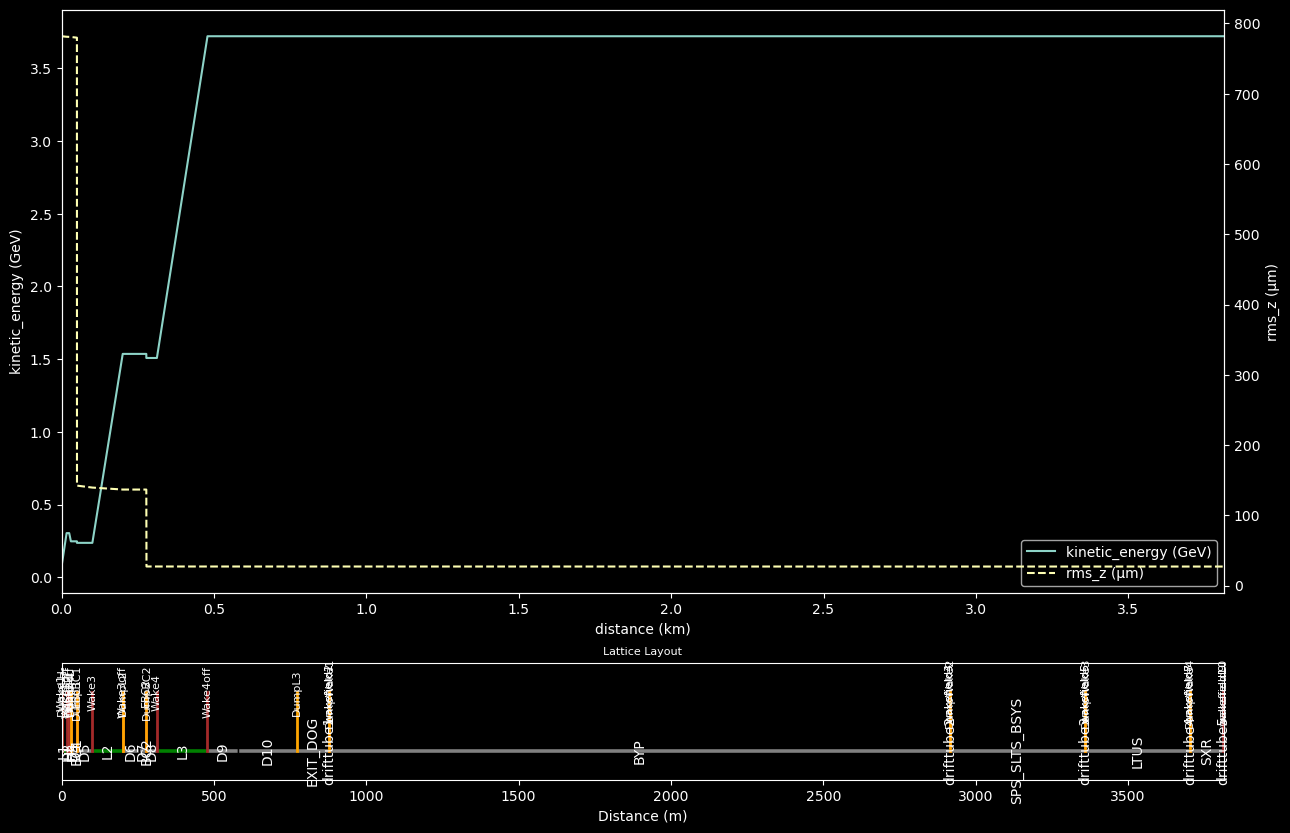

In [93]:
E.plot()

In [94]:
pg = E.output.particle_distributions[201].to_particlegroup()

In [95]:
pg['sigma_t']*1e15

np.float64(90.35270137621897)

In [96]:
pg['sigma_z']

np.float64(2.7087058432516668e-05)

In [97]:
pg.charge

np.float64(6.000000000000001e-11)

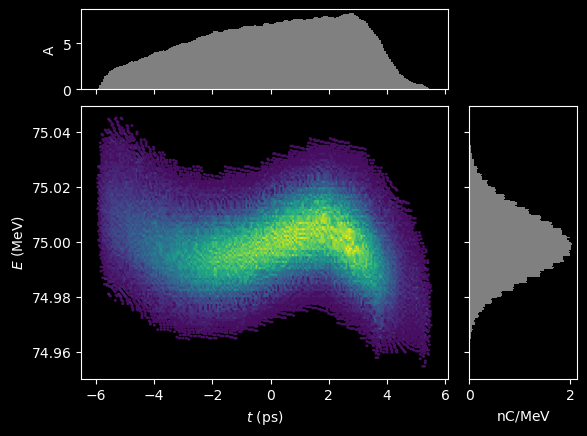

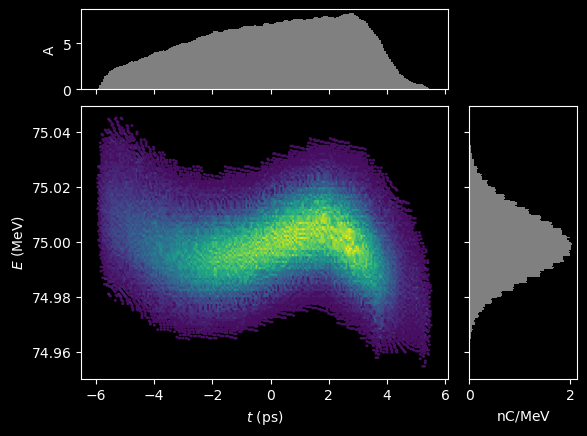

In [103]:
# after BC1
E.output.plot_distribution(file_id = 101, xkey="t", ykey="energy", bins = 200)

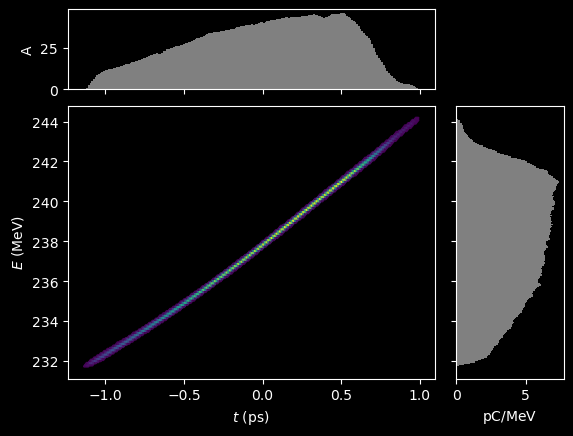

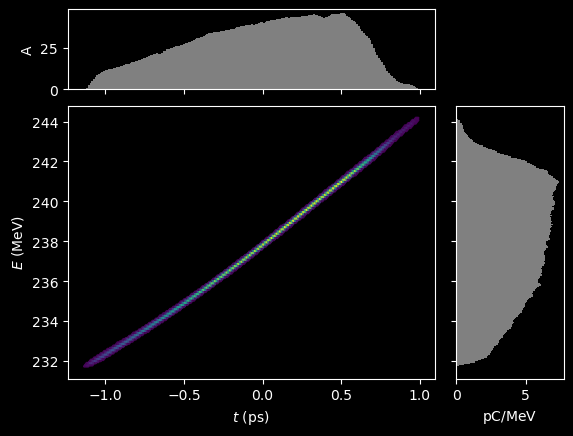

In [98]:
# after BC1
E.output.plot_distribution(file_id = 109, xkey="t", ykey="energy", bins = 200)

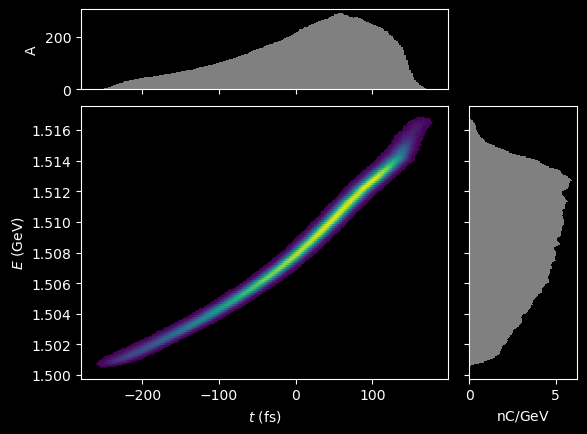

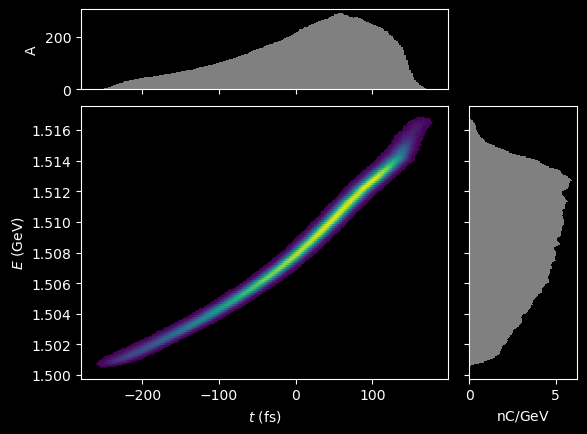

In [99]:
# after BC2
E.output.plot_distribution(file_id = 113, xkey="t", ykey="energy", bins = 200)

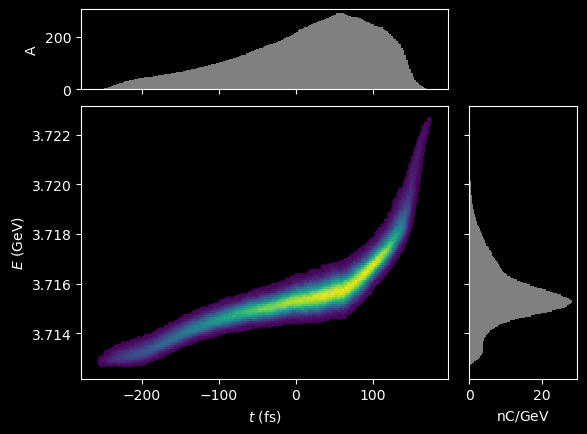

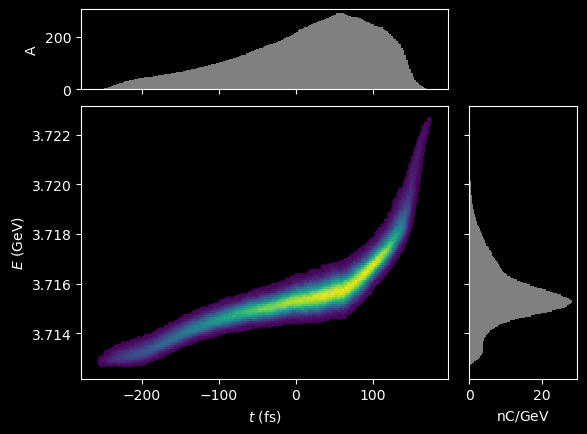

In [100]:
E.output.plot_distribution(file_id = 201, xkey="t", ykey="energy", bins = 200)

In [101]:
settings

{'Impact_particles': '/sdf/data/ad/ard/u/jytang/lume-belt-live/STCAV_data/particle-2025-04-05.h5',
 'BC1:angle': np.float64(0.1012022610854259),
 'BC2:angle': np.float64(0.04682261945235369),
 'L1:gradient': np.float64(15319042.563235678),
 'L1:phase_deg': np.float64(-25.347109915959145),
 'L2:gradient': np.float64(13261032.429405672),
 'L2:phase_deg': np.float64(-10.40325961692651),
 'L3:gradient': np.float64(13325993.233714484),
 'L3:phase_deg': np.float64(0.0),
 'HL:gradient': np.float64(10326024.443383193),
 'HL:phase_deg': np.float64(-171.3455206248097),
 'EBC1:energy_increment': np.float64(-10466144.92697978),
 'EBC2:energy_increment': np.float64(-28072743.93244481)}

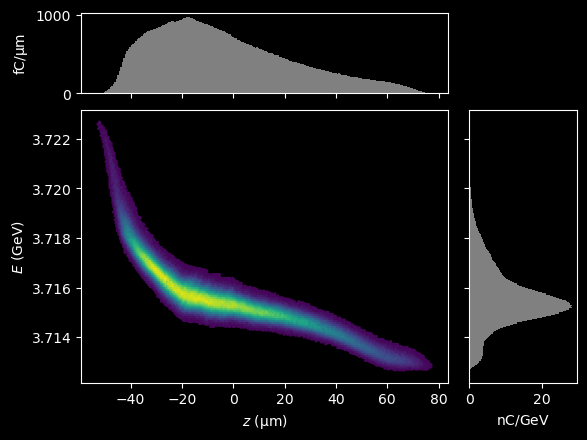

In [102]:
pg.plot('z', 'energy')

In [76]:
pg.write(final_beam)

In [412]:
final_beam

'XTCAV_data/sim/LCLSII-snapshot-2025-04-05T13:17:13-07:00.h5'

In [384]:
E.input.lattice_lines

[WriteBeam(iwrite=102, sample=1, name='DumpLH'),
 Wakefield(length=0.0, multiplier=1.0, wake_function_file_id=41.0, switch=1.0, name='Wake1'),
 RFCavity(length=16.6, beam_radius=0.0003, gradient=np.float64(15319065.043921089), frequency=1300000000.0, phase_deg=np.float64(-25.581063278114264), name='L1'),
 Wakefield(length=0.0, multiplier=1.0, wake_function_file_id=41.0, switch=-1.0, name='Wake1off'),
 DriftTube(length=8.5305163742, beam_radius=0.0003, name='D2'),
 WriteBeam(iwrite=104, sample=1, name='DumpL1'),
 Wakefield(length=0.0, multiplier=1.0, wake_function_file_id=42.0, switch=1.0, name='Wake2'),
 RFCavity(length=5.53, beam_radius=0.0003, gradient=np.float64(9968950.461969564), frequency=3900000000.0, phase_deg=np.float64(-171.03313410549836), name='HL'),
 Wakefield(length=0.0, multiplier=1.0, wake_function_file_id=42.0, switch=-1.0, name='Wake2off'),
 WriteBeam(iwrite=106, sample=1, name='DumpHL'),
 DriftTube(length=12.518616788, beam_radius=0.0003, name='D3'),
 DriftTube(lengt

In [146]:
E.input.parameters

Parameters(np=200000, nz=128, zmin=-0.002981592, zmax=0.002211398, flagfwd=1, flagdist=100, Iavg=np.float64(0.07800000000000001), Ek=74489001.04999998, mass=511005.0, charge=np.float64(6.000000000000001e-11), freq=1300000000.0)

In [104]:
pg = E.output.particle_distributions[109].to_particlegroup()

In [106]:
pg['sigma_z']*1e3

np.float64(0.14225496583881003)

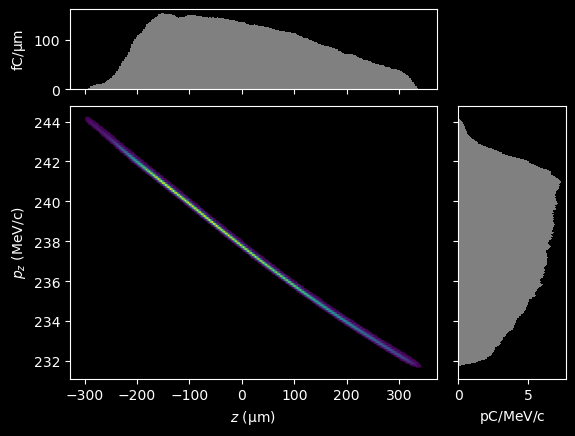

In [107]:
pg.plot('z', 'pz')

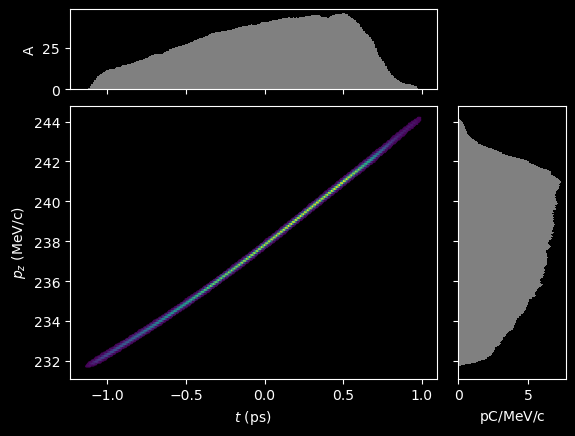

In [108]:
pg.plot('t', 'pz')

In [109]:
pg.charge

np.float64(6.000000000000001e-11)